<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/supervised/regression/experiment_california_housing_regression_ml_dl_xgboost_shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import (
    fetch_california_housing
)

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.linear_model import (
    LinearRegression
)

from sklearn.ensemble import (
    RandomForestRegressor
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

STEP 2 — Load Dataset

In [2]:
housing = fetch_california_housing()

X = housing.data

y = housing.target

STEP 3 — Create DataFrame

In [3]:
df = pd.DataFrame(
    X,
    columns=housing.feature_names
)

df["Price"] = y

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


STEP 4 — Understand Dataset

In [4]:
print(df.info())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
2

STEP 5 — Check Missing Values

In [5]:
print(df.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


STEP 6 — Exploratory Data Analysis

Correlation Matrix

In [6]:
print(df.corr())

              MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc      1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge   -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms    0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms  -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population  0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup    0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude   -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude  -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
Price       0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

            Latitude  Longitude     Price  
MedInc     -0.079809  -0.015176  0.688075  
HouseAge    0.011173  -0.108197  0.105623  
AveRooms    0.106389  -0.027540  0.151948  
AveBedrms   0.069721   0.013344 -0.046701  
Populatio

Plot Histograms

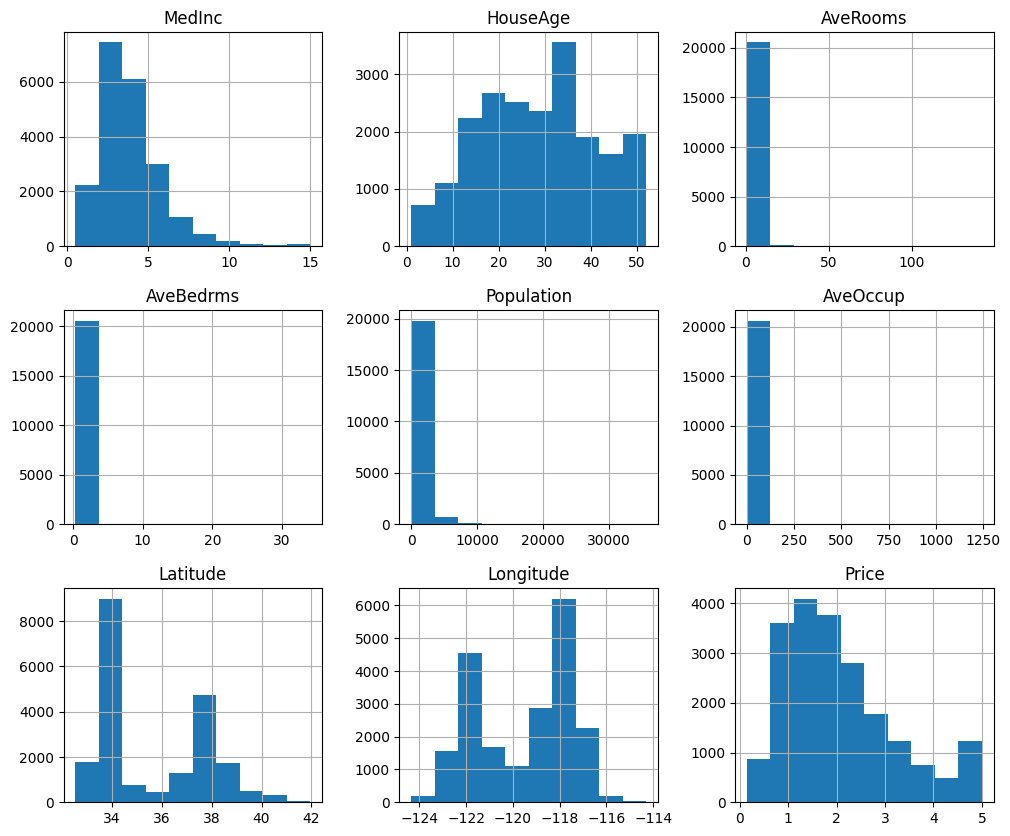

In [7]:
df.hist(
    figsize=(12, 10)
)

plt.show()

Scatter Plot

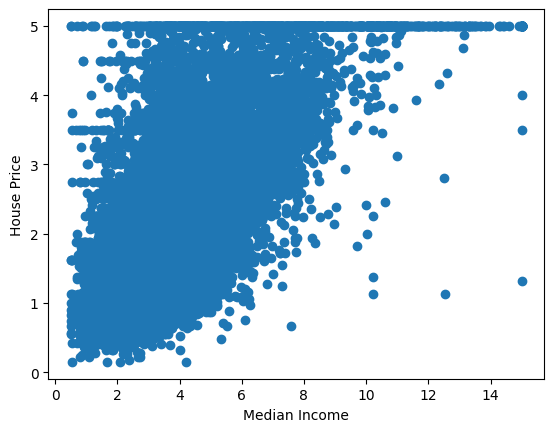

In [8]:
plt.scatter(
    df["MedInc"],
    df["Price"]
)

plt.xlabel("Median Income")

plt.ylabel("House Price")

plt.show()

STEP 7 — Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

STEP 8 — Feature Scaling

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

STEP 9 — Baseline ML Model

In [11]:
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

LinearRegression()

Predictions

In [12]:
lr_predictions = lr_model.predict(
    X_test
)

Evaluate

In [13]:
print(
    "MSE:",
    mean_squared_error(
        y_test,
        lr_predictions
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        lr_predictions
    )
)

MSE: 0.5558915986952442
R2 Score: 0.575787706032451


STEP 10 — Advanced ML Model

In [14]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

Predictions

In [15]:
rf_predictions = rf_model.predict(
    X_test
)

Evaluation

In [16]:
print(
    "Random Forest R2:",
    r2_score(
        y_test,
        rf_predictions
    )
)

Random Forest R2: 0.8052747336256919


STEP 11 — Hyperparameter Tuning

In [17]:
params = {

    "n_estimators": [50, 100],

    "max_depth": [10, 20]
}

grid = GridSearchCV(

    RandomForestRegressor(),

    params,

    cv=3
)

grid.fit(
    X_train,
    y_train
)

print(grid.best_params_)

{'max_depth': 20, 'n_estimators': 100}


STEP 12 — Deep Learning Model

In [18]:
model = Sequential()

# ====================================================
# BLOCK 1
# ====================================================

model.add(
    Dense(
        256,
        activation="relu",
        input_shape=(8,)
    )
)

model.add(BatchNormalization())

model.add(Dropout(0.3))

# ====================================================
# BLOCK 2
# ====================================================

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(BatchNormalization())

model.add(Dropout(0.3))

# ====================================================
# BLOCK 3
# ====================================================

model.add(
    Dense(
        64,
        activation="relu"
    )
)

# ====================================================
# OUTPUT
# ====================================================

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


STEP 13 — Compile Model

In [19]:
model.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]
)

STEP 14 — Configure Callbacks

In [20]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5
)

STEP 15 — Train Deep Learning Model

In [21]:
history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=64,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.9157 - mae: 0.7113 - val_loss: 0.9374 - val_mae: 0.6824 - learning_rate: 0.0010
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5942 - mae: 0.5721 - val_loss: 0.5495 - val_mae: 0.5072 - learning_rate: 0.0010
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5240 - mae: 0.5350 - val_loss: 0.4173 - val_mae: 0.4537 - learning_rate: 0.0010
Epoch 4/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4806 - mae: 0.5071 - val_loss: 0.3951 - val_mae: 0.4375 - learning_rate: 0.0010
Epoch 5/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4390 - mae: 0.4831 - val_loss: 0.4155 - val_mae: 0.4274 - learning_rate: 0.0010
Epoch 6/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4210 - mae: 0.4720 - val_loss: 0.4247 - val_mae: 0.4190 - learning_rate: 0.0010
Epoch 7/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4007 - mae: 0.4575 - val_loss: 0.3826 - val_mae: 0.3995 - learning_rate: 0.001

STEP 16 — Evaluate Deep Learning Model

In [22]:
loss, mae = model.evaluate(
    X_test,
    y_test
)

print("Test MAE:", mae)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2791 - mae: 0.3538
Test MAE: 0.35381942987442017


STEP 17 — Predictions

In [23]:
dl_predictions = model.predict(
    X_test
)

print(dl_predictions[:5])

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
[[0.41550004]
 [0.9158523 ]
 [4.317651  ]
 [2.567983  ]
 [2.618367  ]]


STEP 18 — Compare All Models

In [24]:

# --------------------------------------------
# Linear Regression Metrics
# --------------------------------------------

lr_mse = mean_squared_error(
    y_test,
    lr_predictions
)

lr_mae = mean_absolute_error(
    y_test,
    lr_predictions
)

lr_r2 = r2_score(
    y_test,
    lr_predictions
)

# --------------------------------------------
# Random Forest Metrics
# --------------------------------------------

rf_mse = mean_squared_error(
    y_test,
    rf_predictions
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

# --------------------------------------------
# Deep Learning Predictions
# --------------------------------------------

dl_predictions = model.predict(X_test)

# Convert shape from (n,1) → (n,)
dl_predictions = dl_predictions.flatten()

# --------------------------------------------
# Deep Learning Metrics
# --------------------------------------------

dl_mse = mean_squared_error(
    y_test,
    dl_predictions
)

dl_mae = mean_absolute_error(
    y_test,
    dl_predictions
)

dl_r2 = r2_score(
    y_test,
    dl_predictions
)

# ====================================================
# Create Comparison Table
# ====================================================

comparison_df = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "Deep Neural Network"
    ],

    "MSE": [
        lr_mse,
        rf_mse,
        dl_mse
    ],

    "MAE": [
        lr_mae,
        rf_mae,
        dl_mae
    ],

    "R2 Score": [
        lr_r2,
        rf_r2,
        dl_r2
    ]
})

# ====================================================
# Display Results
# ====================================================

print(comparison_df)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                 Model       MSE       MAE  R2 Score
0    Linear Regression  0.555892  0.533200  0.575788
1        Random Forest  0.255170  0.327425  0.805275
2  Deep Neural Network  0.279080  0.353819  0.787028


Visualization Comparison

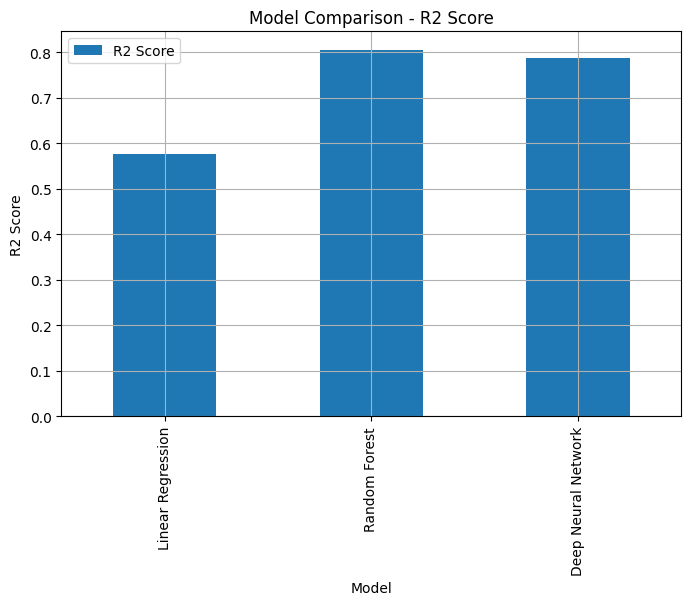

In [25]:


comparison_df.plot(

    x="Model",

    y="R2 Score",

    kind="bar",

    figsize=(8, 5)
)

plt.title("Model Comparison - R2 Score")

plt.ylabel("R2 Score")

plt.grid(True)

plt.show()

In [26]:
# ====================================================
# Select Best Model
# ====================================================

best_model = comparison_df.loc[
    comparison_df["R2 Score"].idxmax()
]

print("\nBest Model:\n")

print(best_model)


Best Model:

Model       Random Forest
MSE               0.25517
MAE              0.327425
R2 Score         0.805275
Name: 1, dtype: object


STEP 19 — Visualize Predictions

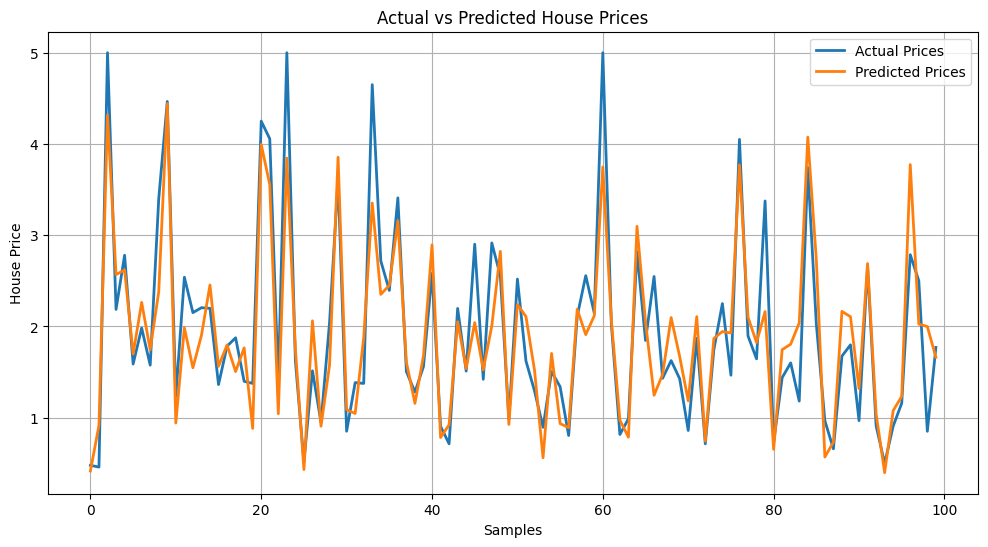

In [27]:

plt.figure(figsize=(12, 6))

# Actual Values
plt.plot(
    y_test[:100],
    label="Actual Prices",
    linewidth=2
)

# Predicted Values
plt.plot(
    dl_predictions[:100],
    label="Predicted Prices",
    linewidth=2
)

plt.title(
    "Actual vs Predicted House Prices"
)

plt.xlabel("Samples")

plt.ylabel("House Price")

plt.legend()

plt.grid(True)

plt.show()

STEP 20 — Save Models

In [28]:
# ====================================================
# Save Random Forest Model
# ====================================================

import pickle

with open(
    "random_forest_model.pkl",
    "wb"
) as file:

    pickle.dump(
        rf_model,
        file
    )

print("Random Forest Model Saved")

Random Forest Model Saved


Save Deep Learning Model

In [29]:
# ====================================================
# Save Deep Learning Model
# ====================================================

model.save(
    "housing_dnn.keras"
)

print("Deep Learning Model Saved")

Deep Learning Model Saved


STEP 21 — Load Saved Models

In [30]:
# ====================================================
# Load Random Forest Model
# ====================================================

with open(
    "random_forest_model.pkl",
    "rb"
) as file:

    loaded_rf_model = pickle.load(file)

print("Random Forest Model Loaded")

Random Forest Model Loaded


In [32]:
# ====================================================
# Load Deep Learning Model
# ====================================================

from tensorflow.keras.models import load_model

loaded_dl_model = load_model(
    "housing_dnn.keras"
)

print("Deep Learning Model Loaded")

Deep Learning Model Loaded


STEP 22 — Predict New House Price

In [33]:
sample = X_test[0].reshape(1, -1)

# Deep Learning Prediction
prediction = loaded_dl_model.predict(sample)

print(
    "Predicted House Price:",
    prediction[0][0]
)

# Actual Value
print(
    "Actual House Price:",
    y_test[0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
Predicted House Price: 0.4155
Actual House Price: 0.477


Feature Importance

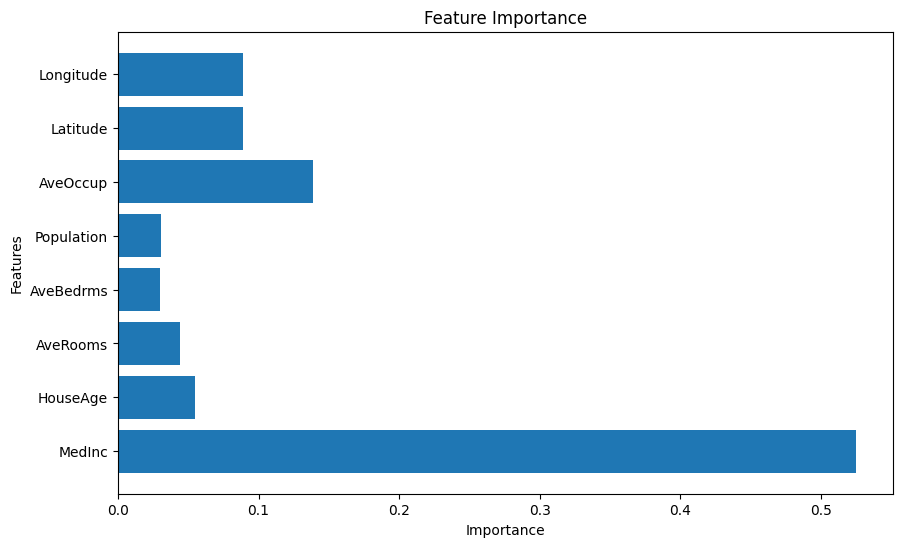

In [34]:
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

features = housing.feature_names

plt.figure(figsize=(10, 6))

plt.barh(features, importance)

plt.xlabel("Importance")

plt.ylabel("Features")

plt.title("Feature Importance")

plt.show()

Residual Error Plot

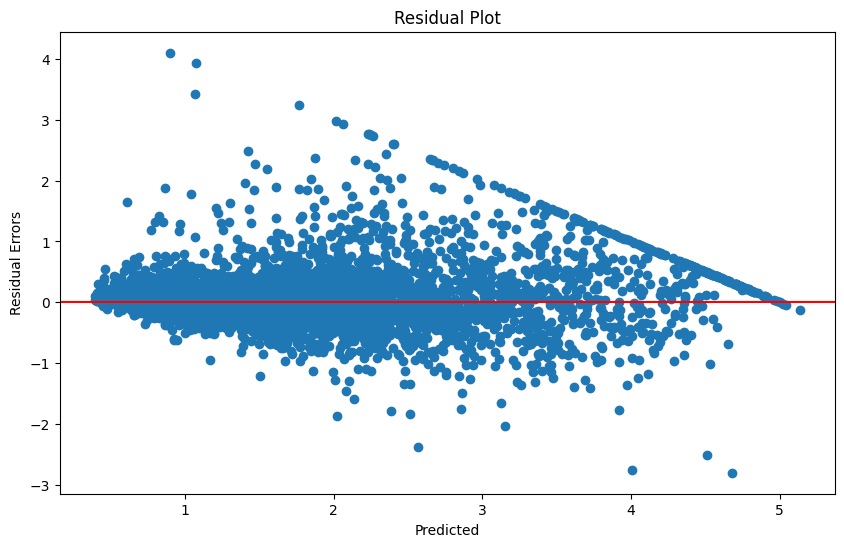

In [35]:
errors = y_test - dl_predictions

plt.figure(figsize=(10, 6))

plt.scatter(
    dl_predictions,
    errors
)

plt.axhline(
    y=0,
    color='r'
)

plt.xlabel("Predicted")

plt.ylabel("Residual Errors")

plt.title("Residual Plot")

plt.show()

Learning Curves

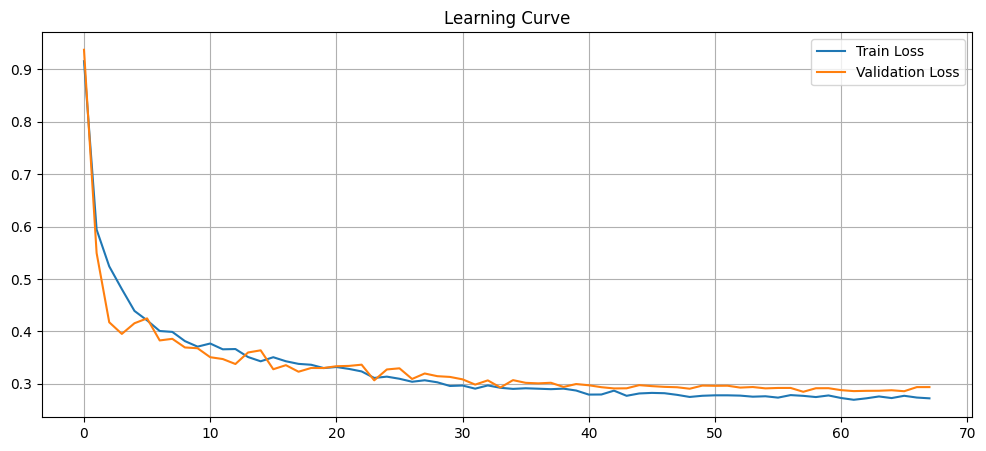

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.grid(True)

plt.title("Learning Curve")

plt.show()

XGBoost Trial

In [37]:
!pip install xgboost

In [38]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor()

xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_model.predict(
    X_test
)

print(
    r2_score(
        y_test,
        xgb_predictions
    )
)

0.8301370561019205


Add Cross Validation

In [39]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(

    rf_model,

    X_train,

    y_train,

    cv=5,

    scoring="r2"
)

print(scores)

print(scores.mean())

[0.80901645 0.79413815 0.80825595 0.80432529 0.80510896]
0.8041689588513355


Add SHAP Explainability

In [40]:
!pip install shap

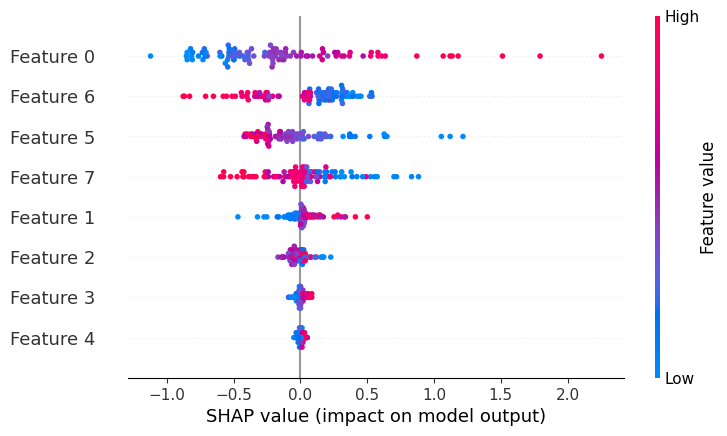

In [41]:
import shap

explainer = shap.Explainer(rf_model)

shap_values = explainer(X_test[:100])

shap.plots.beeswarm(shap_values)